In [27]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd

In [3]:
insurance_data= pd.read_csv('insurance.csv')

In [7]:
X= insurance_data.drop(columns=['charges'])
y= insurance_data['charges']

X= pd.get_dummies(X, columns=['region'], drop_first=True, dtype=int)
X['sex']= X['sex'].map({'female':0, 'male':1})
X['smoker']= X['smoker'].map({'no':0, 'yes':1})

X['age_smoker']= X['age']*X['smoker']
X['bmi_smoker']= X['bmi']*X['smoker']

X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

Alpha: 0.1, MSE: 20921803.698431388
Alpha: 0.001, MSE: 20922599.871035974
Alpha: 0.5, MSE: 20918648.889825623
Alpha: 0.2, MSE: 20921006.729136672
Alpha: 0.05, MSE: 20922205.278698537
Alpha: 0.005, MSE: 20922567.589644518
Alpha: 1, MSE: 20914832.635089148
Alpha: 2, MSE: 20908106.779954527
Alpha: 3, MSE: 20901927.931570236
Alpha: 4, MSE: 20896130.81113566
Alpha: 5, MSE: 20890881.000633504
Alpha: 10, MSE: 20872844.79479669
Alpha: 40, MSE: 21046489.293890767
Alpha: 50, MSE: 21196929.869608894
Alpha: 100, MSE: 22423172.686023228


<Axes: >

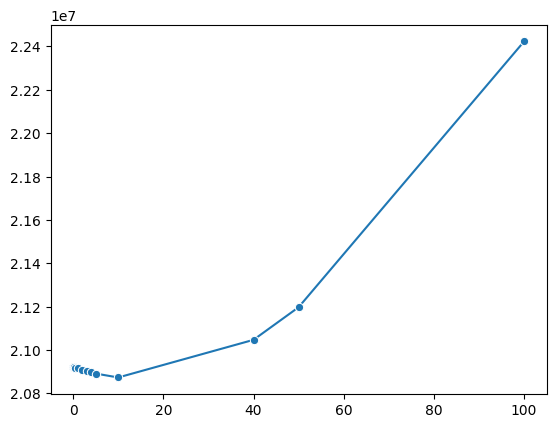

In [20]:
import seaborn as sns 

alpha=[0.1,0.001,0.5,0.2,0.05,0.005, 1,2,3,4,5,10, 40,50,100]
mes_list=[]
for a in alpha:
    lasso_model= linear_model.Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)
    
    y_pred= lasso_model.predict(X_test)
    mes= mean_squared_error(y_test, y_pred)
    print(f"Alpha: {a}, MSE: {mes}")
    mes_list.append(mes)
    
sns.lineplot(x=alpha, y= mes_list, marker="o")

<Axes: >

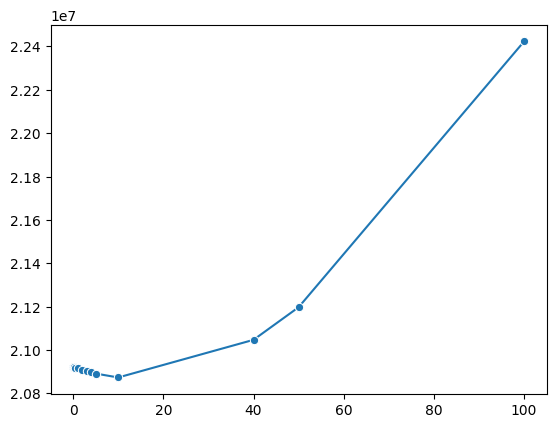

In [21]:
import seaborn as sns 
sns.lineplot(x=alpha, y= mes_list, marker="o")

In [ ]:
from sklearn.linear_model import LassoCV
alpha=[0.1,0.001,0.5,0.2,0.05,0.005, 1,2,3,4,5,10, 40,50,100]
lass_cv_model= LassoCV(
    alphas=alpha,
    cv=5,
    max_iter=1000,
    random_state=42
)
lass_cv_model.fit(X_train, y_train)
print(f"Best alpha: {lass_cv_model.alpha_}")

y_pred= lass_cv_model.predict(X_test)
mes= mean_squared_error(y_test, y_pred)
mes

Best alpha: 0.001


20922599.871035974

In [28]:
r2=r2_score(y_test, y_pred)
r2

0.8652317499151698